In [1]:
import os, sys, glob, importlib, types, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import xgboost as xgb

In [2]:
try:
    nb_path = globals().get('__vsc_ipynb_file__')
    if nb_path:
        os.chdir(os.path.dirname(os.path.dirname(nb_path)))
except Exception as e:
    print(f"Could not change directory: {e}")
print("CWD:", os.getcwd())
%load_ext autoreload
%autoreload 2
import config
cdt = importlib.import_module("04_cross_dataset_training")

# 04 -> lstm_autoencoder_outlier -> outlier_utils does matplotlib.use('Agg') at
# import time, overriding the inline backend. Re-assert it.
%matplotlib inline

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 0. Setup

In [3]:
GROUP_NAME = "final_6_new"
CURVE_TYPE = "ori_curve_sg_p4_norm"
MODEL      = "cnn_gru_dual_attn_recon"
P_PIX      = 290 * 204

BASE = (Path(config.FINAL_EXP_FOLDER) / "cross_dataset_cv" / GROUP_NAME
        / "curve_alignment_pc_ttp" / f"anchor_min")
RES_DIR = BASE / "noamp_remove" / "center0.5"
RAW_ROOT = Path(config.FINAL_EXP_FOLDER)

import re
def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

def chip_sort_key(s):
    m = re.search(r'DDM_0(\d)', s)
    return int(m.group(1)) if m else s

CHIPS = sorted(config.CROSS_DATASET_GROUPS[GROUP_NAME], key=chip_sort_key)

def _arr(x):
    return np.concatenate(x) if isinstance(x, list) else np.asarray(x)

def load_fold(model, chip):
    """Saved LOFO predictions + the per-fold XAI snapshot, row-aligned.

    Returns (y_true, y_pred, well_ids, features_df_post_filter) or None."""
    fold = f"lofo_{chip}"
    rp = RES_DIR / config.CROSS_DATASET_RESULT_PATH_PER_MODEL.format(
        mode="lofo", curve_type=CURVE_TYPE, model=model)
    xp = BASE / "model_interpretation" / fold / f"xai_data_{CURVE_TYPE}.joblib"
    if not rp.exists() or not xp.exists():
        return None
    res = joblib.load(rp)
    if fold not in res:
        return None
    d = res[fold]
    pk = config.MODEL_KEY_MAP[model][0]
    if pk not in d:
        return None
    yt, yp = _arr(d["y_trues_"]), _arr(d[pk])
    wi = _arr(d["well_ids_test_"]) if "well_ids_test_" in d else None
    fdt = joblib.load(xp)["features_df_test"]
    m = fdt[cdt.NOAMP_FILTER_NAME].values == 1
    if int(m.sum()) != len(yt):
        print(f"  [!] {short_name(chip)}: row mismatch xai={int(m.sum())} preds={len(yt)} -- skipped")
        return None
    return yt, yp, wi, fdt[m].reset_index(drop=True), d.get("class_names")

print(f"results dir exists: {RES_DIR.exists()}")
print(f"{len(CHIPS)} chips: {[short_name(c) for c in CHIPS]}")

results dir exists: True
6 chips: ['Chip 01', 'Chip 02', 'Chip 03', 'Chip 04', 'Chip 05', 'Chip 06']


In [4]:
rows = []
chip3 = [c for c in CHIPS if "DDM_03" in c][0]

for chip in CHIPS:
    got = load_fold(MODEL, chip)
    if got is None:
        continue
    yt, yp, wi, fdt, cn = got
    vi = fdt["vref_idx"].values
    acc = 100 * (yt == yp).mean()
    per = {int(v): (int((vi == v).sum()), 100 * (yt[vi == v] == yp[vi == v]).mean())
           for v in np.unique(vi)}
    rows.append({"chip": short_name(chip), "n": len(yt), "acc": acc,
                 "n_slices": len(per),
                 "detail": "  ".join(f"v{v}: n={n} acc={a:.1f}%" for v, (n, a) in per.items())})

df_d1 = pd.DataFrame(rows)
print("Per-chip LOFO accuracy, split by vref slice:\n")
print(df_d1[["chip", "n", "acc", "n_slices", "detail"]].to_string(index=False))
print(f"\nMacro avg across chips: {df_d1['acc'].mean():.2f}%")

Per-chip LOFO accuracy, split by vref slice:

   chip     n       acc  n_slices                                    detail
Chip 01 14669 59.063331         1                     v0: n=14669 acc=59.1%
Chip 02 14796 54.541768         1                     v0: n=14796 acc=54.5%
Chip 03 14872 35.166756         2 v0: n=837 acc=0.0%  v1: n=14035 acc=37.3%
Chip 04 14672 44.172574         1                     v0: n=14672 acc=44.2%
Chip 05 15440 49.281088         1                     v0: n=15440 acc=49.3%
Chip 06 12927 33.727856         1                     v0: n=12927 acc=33.7%

Macro avg across chips: 45.99%


In [5]:
got = load_fold(MODEL, chip3)
yt, yp, wi, fdt, cn = got
vi = fdt["vref_idx"].values
s0 = vi == 0

print(f"Chip 03 dead-slice (vref_idx=0) composition -- n={s0.sum()} ({100*s0.mean():.1f}% of its rows)\n")
print("  true classes:", dict(collections.Counter(cn[i] for i in yt[s0])))
print("  pred classes:", dict(collections.Counter(cn[i] for i in yp[s0])))
print("  wells       :", dict(collections.Counter(str(w).split('::')[-1] for w in wi[s0])))

D1_N_DEAD   = int(s0.sum())
D1_ACC_DEAD = 100 * (yt[s0] == yp[s0]).mean()
D1_FRAC     = 100 * s0.mean()

acc_all  = 100 * (yt == yp).mean()
acc_keep = 100 * (yt[~s0] == yp[~s0]).mean()
print(f"\n  chip 03 acc WITH dead slice   : {acc_all:.2f}%")
print(f"  chip 03 acc WITHOUT dead slice: {acc_keep:.2f}%   (delta {acc_keep-acc_all:+.2f} pp)")

macro_now = df_d1["acc"].mean()
macro_fix = (df_d1.loc[df_d1.chip != "Chip 03", "acc"].sum() + acc_keep) / len(df_d1)
print(f"\n  6-chip macro avg: {macro_now:.2f}% -> {macro_fix:.2f}%  (delta {macro_fix-macro_now:+.2f} pp)")
print("\n  NOTE: these rows are also in the TRAINING pool for the other 5 folds,")
print("        teaching the model that dead-sensor curves belong to a real class.")

Chip 03 dead-slice (vref_idx=0) composition -- n=837 (5.6% of its rows)

  true classes: {'Kp': 826, 'IAV': 2, 'IBV': 2, 'Cov': 4, 'Hadv': 3}
  pred classes: {'Cov': 10, 'Hadv': 820, 'Kp': 7}
  wells       : {'0': 3, '1': 811, '2': 12, '3': 2, '5': 2, '6': 4, '7': 3}

  chip 03 acc WITH dead slice   : 35.17%
  chip 03 acc WITHOUT dead slice: 37.26%   (delta +2.10 pp)

  6-chip macro avg: 45.99% -> 46.34%  (delta +0.35 pp)

  NOTE: these rows are also in the TRAINING pool for the other 5 folds,
        teaching the model that dead-sensor curves belong to a real class.


In [ ]:
THERMAL_REPORT = ["well_2d_temp_npr_mean", "well_temp_lin2d_mean",
                  "temp_group_idx", "num_active_pixels_in_temp_group"]
THERMAL_COLS = ["well_2d_temp_npr_mean", "temp_group_idx",
                "num_active_pixels_in_temp_group"]
print("in LD_FEATURES?", {c: (c in config.LD_FEATURES) for c in THERMAL_REPORT})

# Per-well thermal offset, per chip -- is the spatial gradient reproducible?
recs = []
for chip in CHIPS:
    got = load_fold(MODEL, chip)
    if got is None:
        continue
    yt, yp, wi, fdt, cn = got
    well = np.array([str(w).split("::")[-1] for w in wi])
    ok = (yt == yp)
    for w in np.unique(well):
        s = well == w
        recs.append({"chip": short_name(chip), "well": int(w),
                     "temp": float(np.nanmean(fdt["well_2d_temp_npr_mean"].values[s])),
                     "acc": 100 * ok[s].mean(), "n": int(s.sum()),
                     "target": cn[int(np.bincount(yt[s]).argmax())]})
d2 = pd.DataFrame(recs)

piv = d2.pivot_table(index="well", columns="chip", values="temp")
print("\nPer-well mean thermal value (well_2d_temp_npr_mean), by chip:\n")
print(piv.round(1).to_string())
print("\nSpearman corr of per-well thermal ranking between chip pairs:")
print(piv.corr(method="spearman").round(2).to_string())

in LD_FEATURES? {'well_2d_temp_npr_mean': False, 'well_temp_lin2d_mean': False, 'temp_group_idx': False, 'num_active_pixels_in_temp_group': False}



Per-well mean thermal value (well_2d_temp_npr_mean), by chip:

chip  Chip 01  Chip 02  Chip 03  Chip 04  Chip 05  Chip 06
well                                                      
0       165.7    172.6    198.6    187.6    169.2    183.5
1       188.4    161.2    182.9    151.7    192.7    162.8
2       149.7    146.1    165.4    168.9    148.8    159.0
3       162.7    154.9    162.5    161.3    187.5    142.1
4       152.5    158.0    150.6    194.8    164.9    145.1
5       162.9    143.4    155.6    151.7    149.9    175.7
6       143.3    154.5    164.0    176.2    178.9      NaN
7       180.7    162.5    155.7    175.1    163.7    206.7

Spearman corr of per-well thermal ranking between chip pairs:
chip     Chip 01  Chip 02  Chip 03  Chip 04  Chip 05  Chip 06
chip                                                         
Chip 01     1.00     0.62     0.21    -0.33     0.26     0.64
Chip 02     0.62     1.00     0.36     0.48     0.40     0.50
Chip 03     0.21     0.36     1.00 

Unstratified (n=47 wells): rho=+0.016 p=0.913   <- confounded, for reference only

Within (chip,target) strata: 4 strata with n>=3, mean rho=-0.033, median=+0.000


/tmp/ipykernel_3683675/3245370469.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = spearmanr(g["temp"], g["acc"])


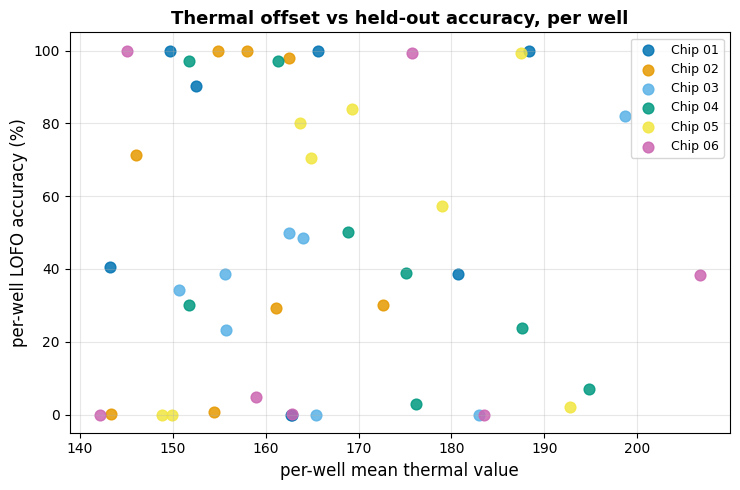

In [ ]:
from scipy.stats import spearmanr

r_all, p_all = spearmanr(d2["temp"], d2["acc"])
print(f"Unstratified (n={len(d2)} wells): rho={r_all:+.3f} p={p_all:.3f}   <- confounded, for reference only")

within = []
for (chip, tgt), g in d2.groupby(["chip", "target"]):
    if len(g) >= 3:
        r, _ = spearmanr(g["temp"], g["acc"])
        if not np.isnan(r):
            within.append(r)
if within:
    print(f"\nWithin (chip,target) strata: {len(within)} strata with n>=3, "
          f"mean rho={np.mean(within):+.3f}, median={np.median(within):+.3f}")
else:
    print("\nToo few wells per (chip,target) stratum for a within-stratum test "
          "-- most chips have 1 well per target.")

fig, ax = plt.subplots(figsize=(7.5, 5))
for chip, g in d2.groupby("chip"):
    ax.scatter(g["temp"], g["acc"], label=chip, s=60, alpha=0.85)
ax.set_xlabel("per-well mean thermal value", fontsize=12)
ax.set_ylabel("per-well LOFO accuracy (%)", fontsize=12)
ax.set_title("Thermal offset vs held-out accuracy, per well", fontsize=13, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
exp_paths = [Path(config.FINAL_EXP_FOLDER, n) for n in CHIPS]
combined = cdt.combine_group(exp_paths, GROUP_NAME, curve_type=CURVE_TYPE)
encoder, y_full, X_cand, *_ = cdt._derive_pool_labels(combined, types.SimpleNamespace(mtl=False))
features_df = combined["features_df"]
splits_raw = cdt.build_lofo_splits(combined["dataset_id"])
lofo_splits = {f"lofo_{c}": splits_raw[f"lofo_{c}"] for c in CHIPS}
print(f"pool: {len(y_full)} rows, classes={list(encoder.classes_)}")

  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1686 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_01_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1828 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_02_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1842 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_03_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1774 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260827_E00_C00_F4500KHz_U_DDM_04_final_final


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_05_01


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 3637 samples from wells [6, 8, 9] (y_label={6: 'IBV', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_06_02


  [*] Resampling curves onto common grid: 903 points, duration=2310


pool: 87906 rows, classes=['Cov', 'Hadv', 'IAV', 'IBV', 'Kp']


In [9]:
XGB_PARAMS = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, objective="multi:softprob",
                  eval_metric="mlogloss", random_state=42, n_jobs=-1)

def _clean(fdf, feats, idx):
    ok = ~fdf.iloc[idx][feats].isna().any(axis=1)
    return idx[ok.to_numpy()]

def _w(y):
    cls, cnt = np.unique(y, return_counts=True)
    inv = {c: len(y)/(len(cls)*n) for c, n in zip(cls, cnt)}
    return np.array([inv[v] for v in y])

def run_lofo(extra_cols, tag):
    out = []
    for fold, (tr, te) in lofo_splits.items():
        top10 = cdt._select_top_10_features(X_cand, y_full, tr, fold)
        feats = list(top10) + list(extra_cols)
        tr2, te2 = _clean(features_df, feats, tr), _clean(features_df, feats, te)
        Xtr = features_df.iloc[tr2][feats].to_numpy(); Xte = features_df.iloc[te2][feats].to_numpy()
        ytr, yte = y_full[tr2], y_full[te2]
        sc = StandardScaler().fit(Xtr)
        m = xgb.XGBClassifier(**XGB_PARAMS)
        m.fit(sc.transform(Xtr), ytr, sample_weight=_w(ytr))
        acc = accuracy_score(yte, m.predict(sc.transform(Xte))) * 100
        out.append({"chip": short_name(fold.replace("lofo_", "")), tag: acc})
    return pd.DataFrame(out).set_index("chip")

base_df = run_lofo([], "top10")
therm_df = run_lofo(THERMAL_COLS, "top10+thermal")
cmp_df = base_df.join(therm_df)
cmp_df["delta"] = cmp_df["top10+thermal"] - cmp_df["top10"]
print(cmp_df.round(2).to_string())
print(f"\nMacro avg: {cmp_df['top10'].mean():.2f}% -> {cmp_df['top10+thermal'].mean():.2f}% "
      f"(delta {cmp_df['delta'].mean():+.2f} pp)")

  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_01_final_final): ['Ct', 'xms', 'Cy0', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'Fb']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_02_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'd2y_xp2', 'xp1', 'd2y_xp1']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_03_final_final): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_04_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cy0', 'Cs', 'Fm', 'Fb', 'd2y_xp2']


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_05_01): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'Fb', 'xp1']


...

  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_03_final_final): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_04_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cy0', 'Cs', 'Fm', 'Fb', 'd2y_xp2']


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_05_01): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'Fb', 'xp1']


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_06_02): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'xp2', 'xp1', 'd2y_xp2']


         top10  top10+thermal  delta
chip                                
Chip 01  54.01          53.73  -0.28
Chip 02  54.26          53.56  -0.70
Chip 03  26.32          26.79   0.46
Chip 04  47.23          43.49  -3.74
Chip 05  41.56          39.35  -2.21
Chip 06  22.72          23.63   0.91

Macro avg: 41.02% -> 40.09% (delta -0.93 pp)


In [10]:
DV = 0.058594  # hard-coded assumed Vref step in linearise.generate_params

def decode_gain(chip, n_refs):
    """Per-pixel A/B/C/D + delta from *_gain.bin. Mirrors linearise.generate_params.

    Layout: 8 equal records, each starting with P*n_refs pixel words
    (Fortran order) followed by a short tail. Record length is inferred."""
    fs = sorted(glob.glob(str(RAW_ROOT / chip / "*_gain.bin")))
    vs = sorted(glob.glob(str(RAW_ROOT / chip / "*_vref_sweep.bin")))
    if not fs:
        return None
    d = np.fromfile(fs[-1], dtype=">u2")
    n_rec = 8
    if len(d) % n_rec != 0:
        print(f"  [!] {short_name(chip)}: gain len {len(d)} not divisible by {n_rec}")
        return None
    rec = len(d) // n_rec
    if rec < P_PIX * n_refs:
        print(f"  [!] {short_name(chip)}: gain record {rec} < P*n_refs {P_PIX*n_refs}")
        return None
    blocks = [d[r * rec: r * rec + P_PIX * n_refs].reshape(290, 204, n_refs, order="F")
              for r in range(n_rec)]
    G = np.stack(blocks, axis=-1).astype(float)   # (290,204,n_refs,8)

    vref = np.fromfile(vs[-1], dtype=">u2")[1:1 + n_refs].astype(float) if vs else np.array([0.]*n_refs)
    out = {}
    for r in range(n_refs):
        tau_i, tau_f = G[:, :, r, 1], G[:, :, r, 3]
        C = G[:, :, r, 7]
        A = 2000.0 + C
        with np.errstate(divide="ignore", invalid="ignore"):
            ld = (tau_i - C) / (tau_f - C)
            B = np.log(np.where(ld > 0, ld, np.nan)) / DV
        D = vref[r] if r < len(vref) else 0.0
        out[r] = {"A": A, "B": B, "C": C, "D": np.full_like(C, D),
                  "delta": G[:, :, r, 1] - G[:, :, r, 3]}
    return out

gain_stats = []
gain_maps = {}
NREFS = dict(zip(d4["chip"], d4["n_refs"])) if "d4" in dir() else {}
for chip in CHIPS:
    nr = int(NREFS.get(short_name(chip), 2 if "DDM_03" in chip else 1))
    g = decode_gain(chip, nr)
    if g is None:
        continue
    gain_maps[chip] = g
    for r, m in g.items():
        b = m["B"][np.isfinite(m["B"])]
        gain_stats.append({"chip": short_name(chip), "vref_idx": r,
                           "B_median": float(np.nanmedian(b)),
                           "delta_mean": float(np.nanmean(m["delta"])),
                           "C_median": float(np.nanmedian(m["C"]))})
print(pd.DataFrame(gain_stats).round(3).to_string(index=False))

   chip  vref_idx  B_median  delta_mean  C_median
Chip 01         0     9.598      73.941       0.0
Chip 02         0     9.732      77.923       0.0
Chip 03         0     9.921       5.283       0.0
Chip 03         1     9.431      70.936       0.0
Chip 04         0    10.399      82.408       0.0
Chip 05         0     9.959      79.961       0.0
Chip 06         0     9.343      72.531       0.0


In [11]:
# Join per-pixel gain onto pool rows and re-run the XGBoost LOFO harness.
gcols = ["gain_B", "gain_delta", "gain_C"]
gvals = {c: np.full(len(features_df), np.nan) for c in gcols}
ds_id = combined["dataset_id"]
rr = features_df["pixel_row_idx"].values.astype(int)
cc = features_df["pixel_col_idx"].values.astype(int)
vv = features_df["vref_idx"].values.astype(int)

for chip, g in gain_maps.items():
    sel = ds_id == chip
    for r, m in g.items():
        s = sel & (vv == r)
        if not s.any():
            continue
        gvals["gain_B"][s]     = m["B"][rr[s], cc[s]]
        gvals["gain_delta"][s] = m["delta"][rr[s], cc[s]]
        gvals["gain_C"][s]     = m["C"][rr[s], cc[s]]

for c in gcols:
    features_df[c] = gvals[c]
    print(f"{c}: nan% = {100*np.isnan(gvals[c]).mean():.1f}")

gain_df = run_lofo(gcols, "top10+gain")
cmp2 = base_df.join(gain_df)
cmp2["delta"] = cmp2["top10+gain"] - cmp2["top10"]
print("\n" + cmp2.round(2).to_string())
print(f"\nMacro avg: {cmp2['top10'].mean():.2f}% -> {cmp2['top10+gain'].mean():.2f}% "
      f"(delta {cmp2['delta'].mean():+.2f} pp)")

gain_B: nan% = 5.9
gain_delta: nan% = 0.0
gain_C: nan% = 0.0


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_01_final_final): ['Ct', 'xms', 'Cy0', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'Fb']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_02_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'Cy0', 'distance_asymmetry_index', 'Cs', 'd2y_xp2', 'xp1', 'd2y_xp1']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_03_final_final): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'd2y_xp2', 'd2y_xp1']


  [*] Selected Top 10 Features (lofo_D20260827_E00_C00_F4500KHz_U_DDM_04_final_final): ['xms', 'Ct', 'first_half_distance', 'second_half_distance', 'distance_asymmetry_index', 'Cy0', 'Cs', 'Fm', 'Fb', 'd2y_xp2']


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_05_01): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'Fm', 'Fb', 'xp1']


  [*] Selected Top 10 Features (lofo_D20260825_E00_C00_F4500KHz_U_DDM_06_02): ['Ct', 'xms', 'first_half_distance', 'Cy0', 'second_half_distance', 'distance_asymmetry_index', 'Cs', 'xp2', 'xp1', 'd2y_xp2']



         top10  top10+gain  delta
chip                             
Chip 01  54.01       54.80   0.79
Chip 02  54.26       53.98  -0.28
Chip 03  26.32       27.30   0.97
Chip 04  47.23       47.95   0.72
Chip 05  41.56       42.50   0.94
Chip 06  22.72       22.91   0.19

Macro avg: 41.02% -> 41.57% (delta +0.56 pp)


In [12]:
def decode_tail(chip):
    fs = sorted(glob.glob(str(RAW_ROOT / chip / "*readout_time.bin")))
    if not fs:
        return None
    d = np.fromfile(fs[-1], dtype=">u2")
    for n_refs in (1, 2, 3):
        A = n_refs + 10
        N = P_PIX * n_refs + A
        if len(d) % N == 0 and int(d[P_PIX * n_refs]) == 11:
            nfr = len(d) // N
            tail = d.reshape(nfr, N)[:, P_PIX * n_refs:]
            ts = tail[:, 1].astype(int)
            vref = tail[:, 2:2 + n_refs].astype(int)
            idx = 2 + n_refs
            return dict(n_refs=n_refs, n_time=nfr, ts=ts, vref=vref,
                        chem=tail[:, idx].astype(int), adc=tail[:, idx + 3].astype(int))
    return None

rows = []
for chip in CHIPS:
    t = decode_tail(chip)
    if t is None:
        print(f"  [!] {short_name(chip)}: decode failed"); continue
    dt = int(np.median(np.diff(t["ts"])))
    ch = np.where(np.diff(t["vref"][:, 0]) != 0)[0]
    step_i = int(ch[0]) if len(ch) else -1
    rows.append({"chip": short_name(chip), "n_refs": t["n_refs"], "n_time": t["n_time"],
                 "dt_s": dt, "vref0": int(t["vref"][0, 0]),
                 "step_frame": step_i,
                 "step_delta": int(t["vref"][step_i + 1, 0] - t["vref"][step_i, 0]) if step_i >= 0 else 0,
                 "step_t_s": int(t["ts"][step_i]) if step_i >= 0 else -1,
                 "adc_drift": int(t["adc"][-1] - t["adc"][0])})
d4 = pd.DataFrame(rows)
print(d4.to_string(index=False))
print(f"\nVref step timing spread: {d4.step_t_s.min()}-{d4.step_t_s.max()} s "
      f"(range {d4.step_t_s.max()-d4.step_t_s.min()} s)")
print(f"Sampling period varies: {sorted(d4.dt_s.unique())} s")

   chip  n_refs  n_time  dt_s  vref0  step_frame  step_delta  step_t_s  adc_drift
Chip 01       1     932     3   3010          49         -33       129         10
Chip 02       1     950     3   3310          31         -31        78         71
Chip 03       2     610     4   2410          36         -32       147         65
Chip 04       1     926     3   2810          44         -33       117         40
Chip 05       1     950     3   2810          28         -22        72         20
Chip 06       1     961     3   2710          32         -22        81         12

Vref step timing spread: 72-147 s (range 75 s)
Sampling period varies: [3, 4] s


In [13]:
# Predicted MSI = step_frame + ~10 (the 20-pt box filter's argmin lands there),
# so implied physical time-since-settling at post-truncation t=0 differs per chip.
d4["msi_pred"] = d4["step_frame"] + 10
d4["t0_phys_s"] = d4["msi_pred"] * d4["dt_s"]
print(d4[["chip", "dt_s", "step_frame", "msi_pred", "t0_phys_s"]].to_string(index=False))
sp = d4["t0_phys_s"].max() - d4["t0_phys_s"].min()
print(f"\nImplied t=0 spread across chips: {sp} s "
      f"({d4['t0_phys_s'].min()}-{d4['t0_phys_s'].max()} s)")

# pc_ttp front-shifts already applied by align_parts_to_pc_ttp, for comparison.
PC_TTP_SHIFT = {"Chip 01": 40.02, "Chip 02": 42.67, "Chip 03": 0.00,
                "Chip 04": 9.04, "Chip 05": 84.07, "Chip 06": 46.41}
d4["pc_ttp_shift_s"] = d4["chip"].map(PC_TTP_SHIFT)
d4["residual_s"] = d4["t0_phys_s"] - d4["pc_ttp_shift_s"]
print("\nDoes pc_ttp compensate the MSI-induced offset, or compound it?\n")
print(d4[["chip", "t0_phys_s", "pc_ttp_shift_s", "residual_s"]].round(1).to_string(index=False))
r, p = spearmanr(d4["t0_phys_s"], d4["pc_ttp_shift_s"])
print(f"\n  rho(t0_phys, pc_ttp_shift) = {r:+.3f} (p={p:.3f}, n=6 -- suggestive only)")
print("  negative rho => pc_ttp partially compensates; positive => compounds.")

   chip  dt_s  step_frame  msi_pred  t0_phys_s
Chip 01     3          49        59        177
Chip 02     3          31        41        123
Chip 03     4          36        46        184
Chip 04     3          44        54        162
Chip 05     3          28        38        114
Chip 06     3          32        42        126

Implied t=0 spread across chips: 70 s (114-184 s)

Does pc_ttp compensate the MSI-induced offset, or compound it?

   chip  t0_phys_s  pc_ttp_shift_s  residual_s
Chip 01        177            40.0       137.0
Chip 02        123            42.7        80.3
Chip 03        184             0.0       184.0
Chip 04        162             9.0       153.0
Chip 05        114            84.1        29.9
Chip 06        126            46.4        79.6

  rho(t0_phys, pc_ttp_shift) = -0.886 (p=0.019, n=6 -- suggestive only)
  negative rho => pc_ttp partially compensates; positive => compounds.


  rho(t0_phys_s     , LOFO acc) = -0.143  p=0.787
  rho(step_t_s      , LOFO acc) = -0.143  p=0.787
  rho(adc_drift     , LOFO acc) = -0.086  p=0.872
  rho(residual_s    , LOFO acc) = -0.086  p=0.872

  n=6 chips -- these carry the MECHANISM, not the statistical weight.
  The per-well (D2) and per-pixel (D1/D3) tests carry the power.


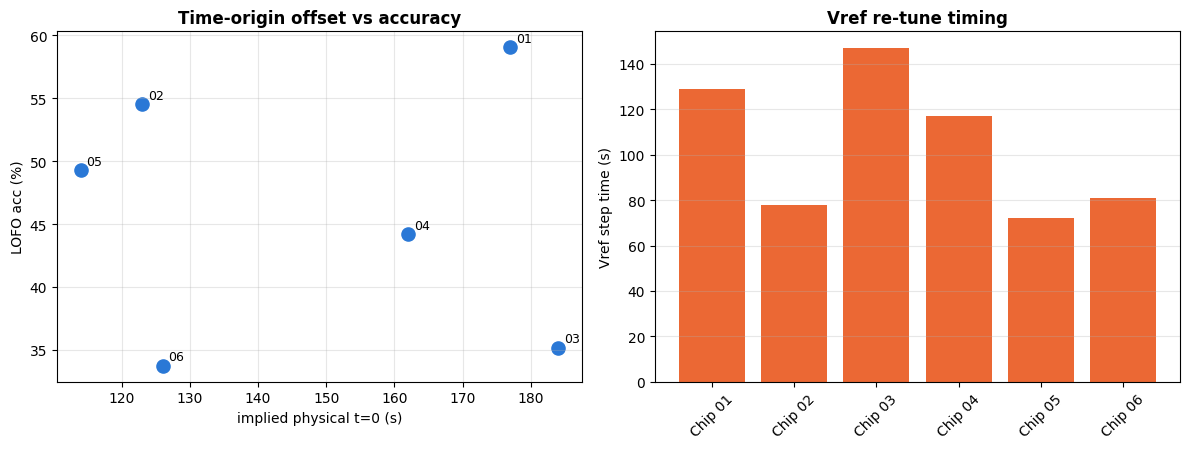

In [14]:
# Suggestive-only association with per-chip LOFO accuracy (n=6).
d4a = d4.merge(df_d1[["chip", "acc"]], on="chip")
for col in ["t0_phys_s", "step_t_s", "adc_drift", "residual_s"]:
    r, p = spearmanr(d4a[col], d4a["acc"])
    print(f"  rho({col:14s}, LOFO acc) = {r:+.3f}  p={p:.3f}")
print("\n  n=6 chips -- these carry the MECHANISM, not the statistical weight.")
print("  The per-well (D2) and per-pixel (D1/D3) tests carry the power.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(d4a["t0_phys_s"], d4a["acc"], s=90, color="#2a78d6")
for _, r_ in d4a.iterrows():
    axes[0].annotate(r_["chip"].replace("Chip ", ""), (r_["t0_phys_s"], r_["acc"]),
                     fontsize=9, xytext=(4, 4), textcoords="offset points")
axes[0].set_xlabel("implied physical t=0 (s)"); axes[0].set_ylabel("LOFO acc (%)")
axes[0].set_title("Time-origin offset vs accuracy", fontweight="bold")
axes[0].grid(alpha=0.3)

axes[1].bar(d4["chip"], d4["step_t_s"], color="#eb6834")
axes[1].set_ylabel("Vref step time (s)"); axes[1].set_title("Vref re-tune timing", fontweight="bold")
axes[1].tick_params(axis="x", rotation=45); axes[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

In [15]:
print("=" * 78)
print("DRIFT DIAGNOSTIC SUMMARY")
print("=" * 78)
print(f"\nD1  dead vref slice (chip 03)")
print(f"      {D1_N_DEAD} rows @ {D1_ACC_DEAD:.1f}% acc "
      f"({D1_FRAC:.1f}% of chip 03)")
print(f"      chip 03: {acc_all:.2f}% -> {acc_keep:.2f}%   macro: {macro_now:.2f}% -> {macro_fix:.2f}%")
print(f"\nD2  thermal covariate (already on disk, unused by models)")
print(f"      XGB LOFO macro: {cmp_df['top10'].mean():.2f}% -> {cmp_df['top10+thermal'].mean():.2f}% "
      f"({cmp_df['delta'].mean():+.2f} pp)")
print(f"\nD3  per-pixel gain covariates")
print(f"      XGB LOFO macro: {cmp2['top10'].mean():.2f}% -> {cmp2['top10+gain'].mean():.2f}% "
      f"({cmp2['delta'].mean():+.2f} pp)")
print(f"\nD4  Vref-step time origin")
print(f"      step timing spread {d4.step_t_s.max()-d4.step_t_s.min()} s; "
      f"implied t=0 spread {sp} s across chips")
print(f"      sampling period varies: {sorted(d4.dt_s.unique())} s")
print("\n" + "=" * 78)

DRIFT DIAGNOSTIC SUMMARY

D1  dead vref slice (chip 03)
      837 rows @ 0.0% acc (5.6% of chip 03)
      chip 03: 35.17% -> 37.26%   macro: 45.99% -> 46.34%

D2  thermal covariate (already on disk, unused by models)
      XGB LOFO macro: 41.02% -> 40.09% (-0.93 pp)

D3  per-pixel gain covariates
      XGB LOFO macro: 41.02% -> 41.57% (+0.56 pp)

D4  Vref-step time origin
      step timing spread 75 s; implied t=0 spread 70 s across chips
      sampling period varies: [3, 4] s

